<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/notebooks/kan_vs_mlp_sp1_1sreda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Часть 1. Генерация данных**

Установка библиотек + проверка устройства

In [42]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-rhh6kduj
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-rhh6kduj
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
Работает на устройстве: cpu


Генерация траекторий численным интегрированием: координата *x(t)*, скорость *v(t)* и ускорение *a(t)*

In [43]:
k, m, c = 4.0, 1.0, 0.3  # жёсткость, масса, сопротивление среды

def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for x0 in [1.0, 0.5, 2.0]: # цикл по начальным условиям
    for v0 in [0.0, 0.5, -0.5]:

        sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 500))
        # запуск численного интегрирования от t[0,20], 500 значений

        x, v = sol.y # извлечение из результата (sol) массив из координат и скоростей
        a = -(k/m)*x - (c/m)*v # вычисление ускорения

        for i in range(len(x)): # сохрание точек (x, v, a)
            all_data.append([x[i], v[i], a[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")   # 9 траекторий × 500 = 4500

Всего точек: 4500


Формирование датасета из полученных данных (входы: *x*,*v*, выход: *a*)

In [44]:
X = all_data[:, :2]   # (x, v)
y = all_data[:, 2]    # a

# pазбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_raw = X_train.astype(np.float32)
X_test_raw  = X_test.astype(np.float32)
y_train_raw = y_train.astype(np.float32).reshape(-1, 1)
y_test_raw  = y_test.astype(np.float32).reshape(-1, 1)

# Тензоры
X_train_t = torch.tensor(X_train_raw, dtype=torch.float32)
y_train_t = torch.tensor(y_train_raw, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_raw, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_raw, dtype=torch.float32)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

train: 3600 примеров, test: 900 примеров


# **Часть 2. Создание и обучение KAN [2,2,1] (66 параметров)**

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.26e-02 | test_loss: 5.18e-02 | reg: 1.64e+01 | : 100%|█| 50/50 [00:13<00:00,  3.63it


saving model version 0.1


| train_loss: 2.00e-02 | test_loss: 2.15e-02 | reg: 1.84e+01 | : 100%|█| 50/50 [00:14<00:00,  3.53it


saving model version 0.2


...

saving model version 0.8


| train_loss: 2.06e-03 | test_loss: 2.16e-03 | reg: 1.64e+01 | : 100%|█| 50/50 [00:11<00:00,  4.44it


saving model version 0.9


| train_loss: 2.04e-03 | test_loss: 2.14e-03 | reg: 1.64e+01 | : 100%|█| 50/50 [00:07<00:00,  6.44it


saving model version 0.10
MSE KAN: 0.00000456


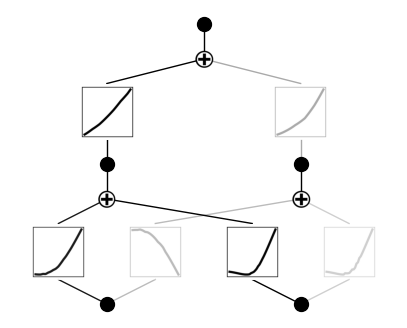

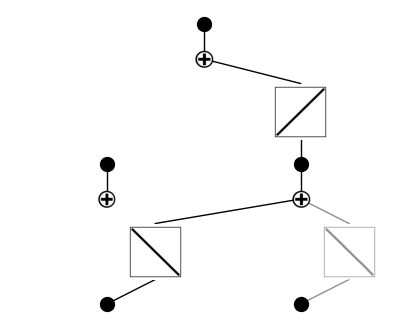

In [50]:
model_kan = KAN(width=[2, 2, 1], grid=10, k=1, seed=42, device=device)
# k=1 так как вычисляемая функция линейна, такого порядка сплайна достаточно

model_kan(dataset['train_input']) # инициализация, визуализация
model_kan.plot()

steps = 10
train_losses_kan = []
test_losses_kan = []
# обучаем по одному шагу, сохраняя потери
for step in range(steps):
    res = model_kan.fit(dataset, opt="LBFGS", steps=50, lamb=0.0, lamb_entropy=0.0)
    train_losses_kan.append(float(res['train_loss'][-1]))
    test_losses_kan.append(float(res['test_loss'][-1]))

model_kan.plot() # визуализация

# конечная ошибка на тесте
with torch.no_grad():
    pred_kan_scaled = model_kan(dataset['test_input'])
    mse_kan_scaled = nn.functional.mse_loss(pred_kan_scaled, dataset['test_label'])
print(f"MSE KAN: {mse_kan_scaled.item():.8f}")

Символьная регрессия

saving model version 0.11
fixing (0,0,0) with x, r2=1.0000001192092896, c=1
fixing (0,1,0) with x, r2=0.9999710917472839, c=1
fixing (1,0,0) with x, r2=1.000000238418579, c=1
saving model version 0.12
Символьная формула KAN: -3.9994*x_1 - 0.2999*x_2 - 0.e-4
Реальная символьная формула: -4.0 + -0.3


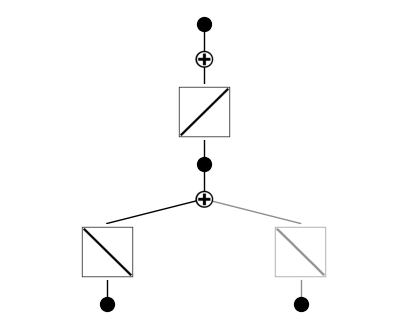

In [46]:
model_kan = model_kan.prune()
model_kan.plot()

lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)

formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN:", formula)
print(f"Реальная символьная формула: {-k/m} + {-c/m}")

# **Часть 3. Создание и обучение MLP [2,16,1] (65 параметров)**

In [53]:
class MLP(nn.Module):
    def __init__(self): # конструктор
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16), # слой
            nn.ReLU(), # функция активации
            nn.Linear(16, 1))
    def forward(self, x): # описывает как данные проходят через сеть
        return self.net(x)

model_mlp = MLP()
criterion = nn.MSELoss() # функция потерь
optimizer = optim.Adam(model_mlp.parameters(), lr=0.01) # оптимизатор

# обучение
epochs = 5000
train_losses_mlp = []
test_losses_mlp = []

for epoch in range(epochs):
    model_mlp.train() # перевод в режим обучения
    optimizer.zero_grad() # обнуление градиентов
    # прямой проход
    pred = model_mlp(dataset['train_input'])
    loss = criterion(pred, dataset['train_label'])
    # обратный проход
    loss.backward()
    optimizer.step()

    if (epoch+1) % 500 == 0:
        model_mlp.eval()
        with torch.no_grad():
            test_loss = criterion(model_mlp(dataset['test_input']), dataset['test_label'])
        print(f"| train loss: {loss.item():.10f} | test loss: {test_loss.item():.10f} | MLP epoch {epoch+1}/{epochs}")

        train_losses_mlp.append(loss.item())
        test_losses_mlp.append(test_loss.item())

# финальная ошибка
model_mlp.eval()
with torch.no_grad():
    pred_mlp_scaled = model_mlp(dataset['test_input'])
    mse_mlp_scaled = criterion(pred_mlp_scaled, dataset['test_label'])
print(f"MSE MLP: {mse_mlp_scaled.item():.12f}")

| train loss: 0.0001257951 | test loss: 0.0001027630 | MLP epoch 500/5000
| train loss: 0.0000231275 | test loss: 0.0000115992 | MLP epoch 1000/5000
| train loss: 0.0000042126 | test loss: 0.0000013225 | MLP epoch 1500/5000
| train loss: 0.0000010507 | test loss: 0.0000002099 | MLP epoch 2000/5000
| train loss: 0.0000003104 | test loss: 0.0000000553 | MLP epoch 2500/5000
| train loss: 0.0000001745 | test loss: 0.0000000225 | MLP epoch 3000/5000
| train loss: 0.0000003905 | test loss: 0.0000002234 | MLP epoch 3500/5000
| train loss: 0.0001454372 | test loss: 0.0000756644 | MLP epoch 4000/5000
| train loss: 0.0000021576 | test loss: 0.0000031389 | MLP epoch 4500/5000
| train loss: 0.0000000258 | test loss: 0.0000000149 | MLP epoch 5000/5000
MSE MLP: 0.000000014900


# **График MSE от шагов/эпох**

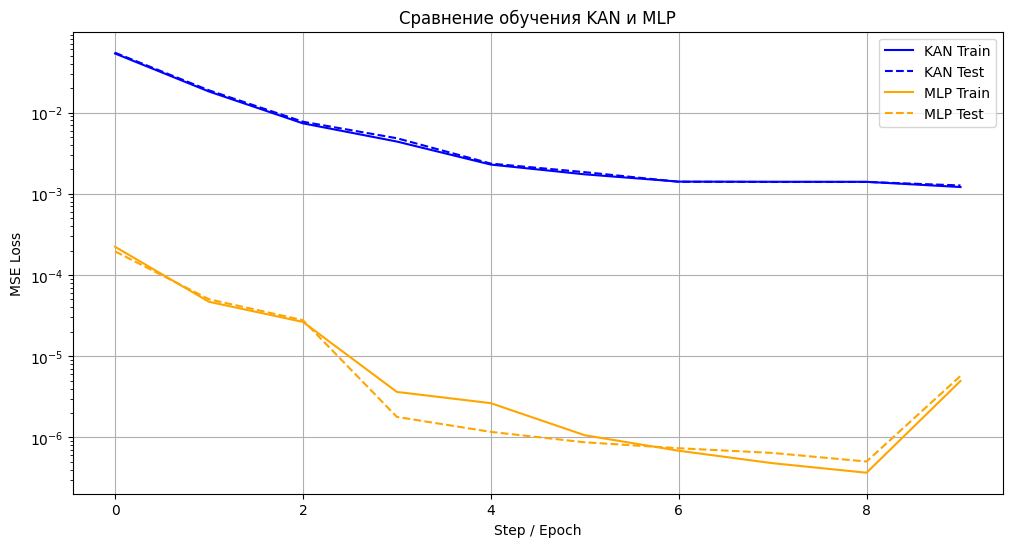

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(train_losses_kan, label='KAN Train', color='blue', linestyle='-')
plt.plot(test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')

plt.plot(train_losses_mlp, label='MLP Train', color='orange', linestyle='-')
plt.plot(test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')

plt.xlabel('Step / Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.title('Сравнение обучения KAN и MLP')
plt.show()

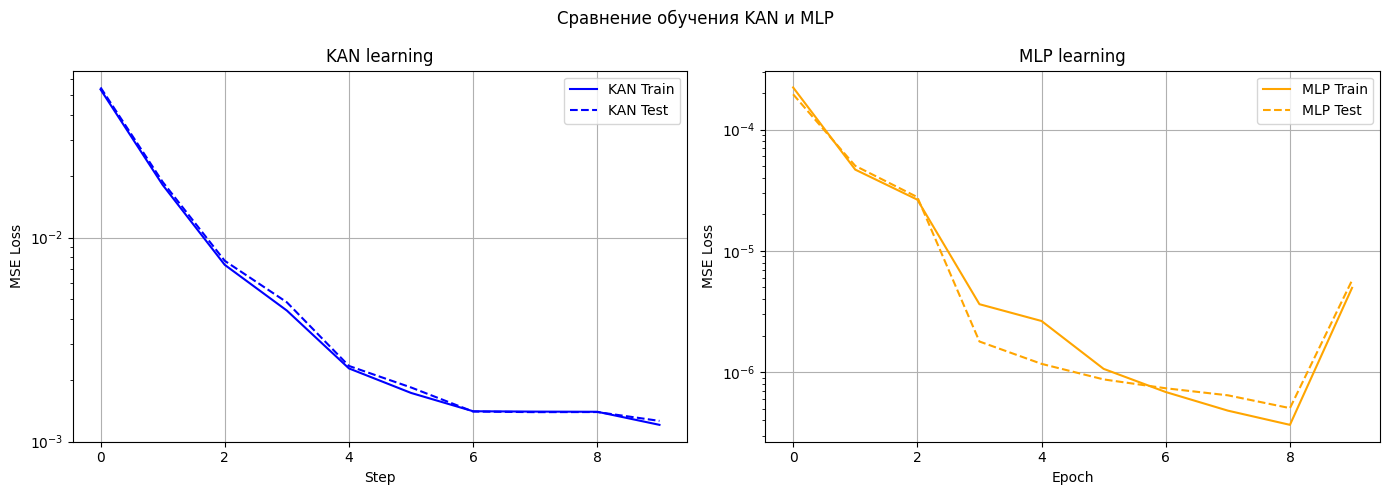

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_kan, label='KAN Train', color='blue')
ax1.plot(test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True)
ax1.set_title('KAN learning')

ax2.plot(train_losses_mlp, label='MLP Train', color='orange')
ax2.plot(test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True)
ax2.set_title('MLP learning')

plt.suptitle('Сравнение обучения KAN и MLP')
plt.tight_layout()
plt.show()